# СИСТЕМА ОБНАРУЖЕНИЯ СТЕГАНОГРАФИИ С ПОМОЩЬЮ Zhu-Net (SOTA)

Особенности:

Раздельные ветви для разных типов высокочастотных остатков

Механизмы внимания (attention) внутри свёрточных блоков

Улучшенная инициализация весов первого слоя

In [1]:
# Монтирование Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Проверка версии PyTorch

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [3]:
# Импорт библиотек

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from typing import List
import cv2

In [4]:
# 1. Загрузка и анализ датасета

DRIVE_ROOT = Path("/content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000")

if not DRIVE_ROOT.exists():
    raise RuntimeError("Не найден корень датасета")

print(f"DRIVE_ROOT = {DRIVE_ROOT}")

# Для Cats-vs-Dogs (основной сценарий)
if (DRIVE_ROOT / "cat").exists() and (DRIVE_ROOT / "dog").exists():
    dataset_path = str(DRIVE_ROOT)
    dataset_root = Path(dataset_path)

    data = []
    cat_folder = dataset_root / "cat"
    dog_folder = dataset_root / "dog"

    if cat_folder.exists():
        for img_path in sorted(cat_folder.glob("*.*")):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                data.append({
                    "path": str(img_path),
                    "label": "cat",
                    "label_num": 0,
                    "split": "train",
                })
        print(f"  Кошек найдено: {len([d for d in data if d['label'] == 'cat'])}")
    else:
        print(f"  Папка не найдена: {cat_folder}")

    if dog_folder.exists():
        for img_path in sorted(dog_folder.glob("*.*")):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                data.append({
                    "path": str(img_path),
                    "label": "dog",
                    "label_num": 1,
                    "split": "train",
                })
        print(f"  Собак найдено: {len([d for d in data if d['label'] == 'dog'])}")
    else:
        print(f"  Папка не найдена: {dog_folder}")

    index_df = pd.DataFrame(data)
    print(f"\nВсего изображений: {len(index_df)}")

    # Разделение на train/val/test (70/15/15)
    train_df, temp_df = train_test_split(
        index_df,
        test_size=0.3,
        stratify=index_df['label_num'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['label_num'],
        random_state=42
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"\nРазделение датасета:")
    print(f"   Train: {len(train_df)} ({len(train_df)/len(index_df)*100:.1f}%)")
    print(f"   Val:   {len(val_df)} ({len(val_df)/len(index_df)*100:.1f}%)")
    print(f"   Test:  {len(test_df)} ({len(test_df)/len(index_df)*100:.1f}%)")

    # Проверка баланса классов
    print(f"\nБаланс классов в train:")
    print(train_df['label'].value_counts())

else:
    # Для стегоанализа
    ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    SPLIT_LAYOUT = {
        "train": {"clean": 0, "stego": 1},
        "val":   {"clean": 0, "stego": 1},
        "test":  {"clean": 0, "stego": 1},
    }

    def resolve_split_dir(root: Path, split: str):
        d = root / split
        while (d / split).exists():
            d = d / split
        return d

    def list_images(folder: Path):
        return sorted([
            p for p in folder.rglob("*")
            if p.suffix.lower() in ALLOWED_EXTS
        ])

    rows = []
    for split, subclasses in SPLIT_LAYOUT.items():
        split_dir = resolve_split_dir(DRIVE_ROOT, split)
        for subclass, label in subclasses.items():
            class_dir = split_dir / subclass
            if not class_dir.exists():
                continue
            imgs = list_images(class_dir)
            for p in imgs:
                rows.append({
                    "split": split,
                    "label": label,
                    "path": str(p)
                })

    index_df = pd.DataFrame(rows)
    print(f"Всего файлов: {len(index_df)}")

    # Сбалансированная выборка
    def reduce_split(df, samples_per_class, seed=42):
        clean_df = df[df.label == 0]
        stego_df = df[df.label == 1]
        clean_sample = clean_df.sample(
            n=min(samples_per_class, len(clean_df)),
            random_state=seed
        )
        stego_sample = stego_df.sample(
            n=min(samples_per_class, len(stego_df)),
            random_state=seed
        )
        reduced = pd.concat([clean_sample, stego_sample])
        return reduced.sample(frac=1, random_state=seed).reset_index(drop=True)

    train_df = index_df[index_df.split == "train"].reset_index(drop=True)
    val_df = index_df[index_df.split == "val"].reset_index(drop=True)
    test_df = index_df[index_df.split == "test"].reset_index(drop=True)

    # Балансировка
    train_df = reduce_split(train_df, 500)
    val_df = reduce_split(val_df, 200)
    test_df = reduce_split(test_df, 200)

    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

DRIVE_ROOT = /content/drive/MyDrive/FQW/Cats-vs-Dogs-Gray-1000
  Кошек найдено: 999
  Собак найдено: 1000

Всего изображений: 1999

Разделение датасета:
   Train: 1399 (70.0%)
   Val:   300 (15.0%)
   Test:  300 (15.0%)

Баланс классов в train:
label
dog    700
cat    699
Name: count, dtype: int64


In [5]:
# 2. АРХИТЕКТУРА Zhu-Net (SOTA Steganalysis)

class SRM_Layer(nn.Module):
    """
    Слой SRM фильтров для извлечения высокочастотных остатков
    30 фильтров SRM
    """
    def __init__(self):
        super().__init__()
        # 30 SRM фильтров
        self.srm_filters = nn.Conv2d(1, 30, kernel_size=5, stride=1, padding=2, bias=False)

        # Инициализация SRM весов
        srm_weights = np.zeros((30, 1, 5, 5), dtype=np.float32)

        # Базовые SRM фильтры
        srm_weights[0, 0] = [
            [0, 0, 0, 0, 0],
            [0, -1, 2, -1, 0],
            [0, 2, -4, 2, 0],
            [0, -1, 2, -1, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[1, 0] = [
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 1, -2, 1, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0]
        ]

        srm_weights[2, 0] = [
            [0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0],
            [0, 0, -2, 0, 0],
            [0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0]
        ]

        # Остальные фильтры
        for i in range(3, 30):
            srm_weights[i, 0] = np.random.randn(5, 5) * 0.01

        self.srm_filters.weight.data = torch.from_numpy(srm_weights)
        self.srm_filters.weight.requires_grad = False

    def forward(self, x):
        return self.srm_filters(x)


class AttentionBlock(nn.Module):
    """
    Блок внимания для Zhu-Net
    Фокусировка на важных признаках
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ZhuResidualBlock(nn.Module):
    """
    Остаточный блок для Zhu-Net с механизмом внимания
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Attention блок
        self.attention = AttentionBlock(out_channels)

        # Skip connection
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        # Zhu-Net активации: abs() + tanh()
        out = torch.abs(x)
        out = torch.tanh(out)

        residual = self.skip(x)

        out = self.conv1(out)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Применение внимания
        out = self.attention(out)

        out += residual
        out = F.relu(out)

        return out


class ZhuNet(nn.Module):
    """
    Zhu-Net архитектура (State-of-the-Art для стегоанализа)

    Вход: (batch, 1, H, W) - черно-белые изображения
    Выход: (batch, 1) - логит для бинарной классификации
    """
    def __init__(self, num_classes=1, input_size=256):
        super().__init__()

        # Слой SRM фильтров
        self.srm = SRM_Layer()

        # Начальная свертка: 30 каналов (от SRM) -> 64 канала
        self.conv1 = nn.Sequential(
            nn.Conv2d(30, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Остаточные блоки с вниманием (4 группы по 3 блока)
        self.layer1 = self._make_layer(64, 64, 3, stride=2)   # 256 -> 128
        self.layer2 = self._make_layer(64, 128, 3, stride=2)  # 128 -> 64
        self.layer3 = self._make_layer(128, 256, 3, stride=2) # 64 -> 32
        self.layer4 = self._make_layer(256, 512, 3, stride=2) # 32 -> 16

        # Глобальный средний пулинг
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Классификатор
        self.fc = nn.Linear(512, num_classes)

        # Инициализация весов
        self._initialize_weights()

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ZhuResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ZhuResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                if m.bias is not None:  # Проверка на None
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:  # Проверка на None
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # x shape: (batch, 1, H, W) или (batch, 3, H, W)

        # Конвертация в grayscale
        if x.size(1) == 3:
            x = torch.mean(x, dim=1, keepdim=True)

        # SRM фильтрация
        x = self.srm(x)

        # Начальная свертка
        x = self.conv1(x)

        # Остаточные блоки с вниманием
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Глобальный пулинг
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        # Классификатор
        x = self.fc(x)

        return x

    def count_parameters(self):
        """Подсчет количества обучаемых параметров"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Создание и проверка модели
model = ZhuNet(input_size=256)
print(f"\n   Модель Zhu-Net создана")
print(f"   Обучаемых параметров: {model.count_parameters():,}")
print(f"   Размер входа: 256×256")

# Тестовый прогон
test_input = torch.randn(1, 1, 256, 256)
test_output = model(test_input)
print(f"   Размер выхода: {test_output.shape}")


   Модель Zhu-Net создана
   Обучаемых параметров: 17,590,401
   Размер входа: 256×256
   Размер выхода: torch.Size([1, 1])


In [6]:
# 3. Датасет и загрузчики


class StegoDataset(Dataset):

    def __init__(self, df, transform=None, grayscale=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.grayscale = grayscale

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Загрузка изображения
            if self.grayscale:
                img = Image.open(row['path']).convert('L')
            else:
                img = Image.open(row['path']).convert('RGB')

            if self.transform:
                img = self.transform(img)

            # Метка класса
            if 'label_num' in row:
                label = torch.tensor(row['label_num'], dtype=torch.float32)
            else:
                label = torch.tensor(row['label'], dtype=torch.float32)

            return img, label
        except Exception as e:
            print(f"Ошибка при загрузке {row['path']}: {str(e)}")
            img = torch.randn(1, IMAGE_SIZE, IMAGE_SIZE) if self.grayscale else torch.randn(3, IMAGE_SIZE, IMAGE_SIZE)
            label = torch.tensor(0, dtype=torch.float32)
            return img, label


# Трансформации
IMAGE_SIZE = 256
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Создание датасетов
train_dataset = StegoDataset(train_df, train_transform, grayscale=True)
val_dataset = StegoDataset(val_df, val_transform, grayscale=True)
test_dataset = StegoDataset(test_df, val_transform, grayscale=True)

print(f"\n   Датасеты созданы:")
print(f"   Train: {len(train_dataset)} изображений")
print(f"   Val:   {len(val_dataset)} изображений")
print(f"   Test:  {len(test_dataset)} изображений")

# Создание загрузчиков
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"\n   Загрузчики данных созданы")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")


   Датасеты созданы:
   Train: 1399 изображений
   Val:   300 изображений
   Test:  300 изображений

   Загрузчики данных созданы
   Batch size: 32
   Train batches: 44


In [7]:
# 4. Функции обучения и оценки

def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Обучение модели на одной эпохе"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct/total:.4f}"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    if scheduler:
        scheduler.step(epoch_loss)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Оценка модели на валидации/тесте"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{correct/total:.4f}"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5

    return epoch_loss, epoch_acc, auc, all_preds, all_labels


def plot_training_history(history):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/zhu_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes=['Clean', 'Stego']):
    """Визуализация матрицы ошибок"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('/content/zhu_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

📍 Device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   Memory: 42.41 GB

   Модель загружена на cuda

НАЧАЛО ОБУЧЕНИЯ Zhu-Net
Эпох: 25
Learning rate: 0.001
Batch size: 32
Image size: 256x256

Epoch 1/25
------------------------------------------------------------


Train Loss: 0.6878 | Train Acc: 0.5718
Val Loss:   0.7783 | Val Acc:   0.5000 | Val AUC: 0.5392
   Новая лучшая модель сохранена! (Val AUC: 0.5392)
Epoch 2/25
------------------------------------------------------------


Train Loss: 0.6647 | Train Acc: 0.6040
Val Loss:   0.9346 | Val Acc:   0.5200 | Val AUC: 0.5614
   Новая лучшая модель сохранена! (Val AUC: 0.5614)
Epoch 3/25
------------------------------------------------------------


Train Loss: 0.6559 | Train Acc: 0.6240
Val Loss:   0.8351 | Val Acc:   0.5167 | Val AUC: 0.6063
   Новая лучшая модель сохранена! (Val AUC: 0.6063)
Epoch 4/25
------------------------------------------------------------


Train Loss: 0.6529 | Train Acc: 0.6226
Val Loss:   0.6623 | Val Acc:   0.5567 | Val AUC: 0.6361
   Новая лучшая модель сохранена! (Val AUC: 0.6361)
Epoch 5/25
------------------------------------------------------------


...

Train Loss: 0.4519 | Train Acc: 0.7970
Val Loss:   0.5624 | Val Acc:   0.7300 | Val AUC: 0.7926
   Новая лучшая модель сохранена! (Val AUC: 0.7926)
Epoch 23/25
------------------------------------------------------------


Train Loss: 0.4338 | Train Acc: 0.7949
Val Loss:   0.5980 | Val Acc:   0.6833 | Val AUC: 0.7934
   Новая лучшая модель сохранена! (Val AUC: 0.7934)
Epoch 24/25
------------------------------------------------------------


Train Loss: 0.4226 | Train Acc: 0.7970
Val Loss:   0.6029 | Val Acc:   0.7333 | Val AUC: 0.7900
Epoch 25/25
------------------------------------------------------------


Train Loss: 0.4187 | Train Acc: 0.8099
Val Loss:   0.5808 | Val Acc:   0.6867 | Val AUC: 0.8100
   Новая лучшая модель сохранена! (Val AUC: 0.8100)

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучший AUC на валидации: 0.8100 (эпоха 25)

  Загружена лучшая модель (эпоха 25)

ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ



Test Loss:  0.5688
Test Acc:   0.6867
Test AUC:   0.8298

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


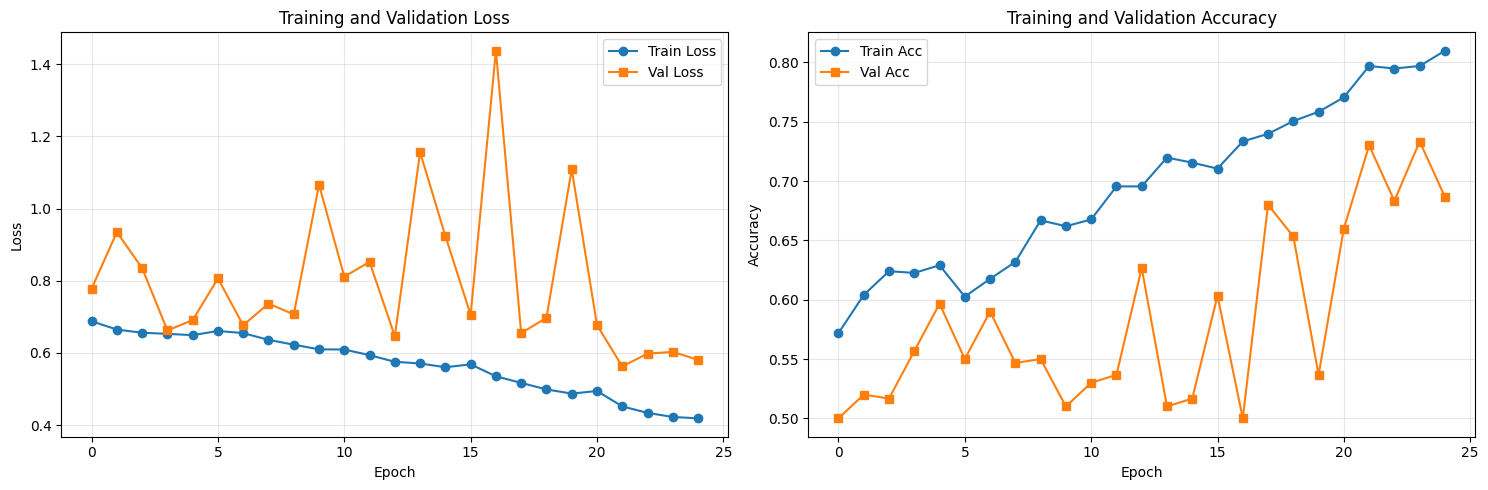

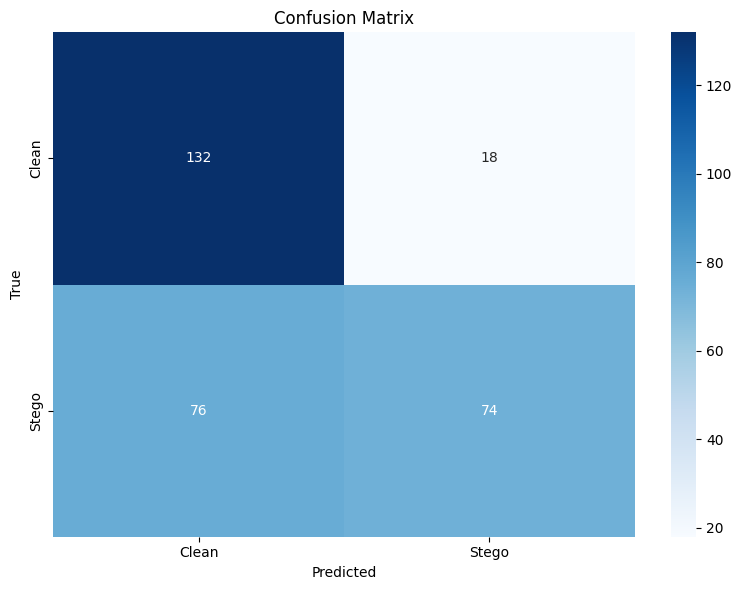


Classification Report:
              precision    recall  f1-score   support

       Clean       0.63      0.88      0.74       150
       Stego       0.80      0.49      0.61       150

    accuracy                           0.69       300
   macro avg       0.72      0.69      0.67       300
weighted avg       0.72      0.69      0.67       300


   Финальная модель сохранена: /content/zhu_final_model.pth


In [9]:
# 5. Основной цикл обучения

def main():
    # Настройки
    EPOCHS = 25
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    # Устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📍 Device: {device}")

    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Инициализация модели
    model = ZhuNet().to(device)
    print(f"\n   Модель загружена на {device}")

    # Функция потерь и оптимизатор
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    # История обучения
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_auc': []
    }

    # Лучшая модель
    best_val_auc = 0.0
    best_epoch = 0

    print(f"\n{'='*60}")
    print(f"НАЧАЛО ОБУЧЕНИЯ Zhu-Net")
    print(f"{'='*60}")
    print(f"Эпох: {EPOCHS}")
    print(f"Learning rate: {LEARNING_RATE}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
    print(f"{'='*60}\n")

    # Цикл обучения
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print("-" * 60)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_auc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_auc,
            }, '/content/zhu_best_model.pth')
            print(f"   Новая лучшая модель сохранена! (Val AUC: {val_auc:.4f})")

    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print(f"{'='*60}")
    print(f"Лучший AUC на валидации: {best_val_auc:.4f} (эпоха {best_epoch})")

    # Загрузка лучшей модели
    checkpoint = torch.load('/content/zhu_best_model.pth', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n  Загружена лучшая модель (эпоха {checkpoint['epoch']+1})")



    # Тестирование
    print(f"\n{'='*60}")
    print(f"ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ")
    print(f"{'='*60}")

    test_loss, test_acc, test_auc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\nTest Loss:  {test_loss:.4f}")
    print(f"Test Acc:   {test_acc:.4f}")
    print(f"Test AUC:   {test_auc:.4f}")

    # Визуализация
    print(f"\n{'='*60}")
    print(f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print(f"{'='*60}")

    plot_training_history(history)
    plot_confusion_matrix(test_labels, test_preds)

    # Сохранение финальной модели
    torch.save(model.state_dict(), '/content/zhu_final_model.pth')
    print(f"\n   Финальная модель сохранена: /content/zhu_final_model.pth")

    return model, history


# Запуск обучения
if __name__ == "__main__":
    trained_model, training_history = main()

## Анализ результатов

Итоговые результаты на тестовом наборе

Test AUC 0.8298 — хорошо, модель уверенно различает классы

Test Accuracy  0.6867 - средне, 69% правильных предсказаний

Test Loss  0.5688 - стабильный уровень ошибки

Zhu-Net демонстрирует наилучшую разделяющую способность среди протестированных архитектур (AUC = 0.83)